In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df=pd.read_excel("Data_Train.xlsx")
train_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
test_df=pd.read_excel("Test_set.xlsx")
test_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [4]:
final_df=pd.concat([train_df,test_df], ignore_index=True)
final_df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
13349,Air India,6/06/2019,Kolkata,Banglore,CCU → DEL → BLR,20:30,20:25 07 Jun,23h 55m,1 stop,No info,NaN
13350,IndiGo,27/03/2019,Kolkata,Banglore,CCU → BLR,14:20,16:55,2h 35m,non-stop,No info,NaN
13351,Jet Airways,6/03/2019,Delhi,Cochin,DEL → BOM → COK,21:50,04:25 07 Mar,6h 35m,1 stop,No info,NaN
13352,Air India,6/03/2019,Delhi,Cochin,DEL → BOM → COK,04:00,19:15,15h 15m,1 stop,No info,NaN
13353,Multiple carriers,15/06/2019,Delhi,Cochin,DEL → BOM → COK,04:55,19:15,14h 20m,1 stop,No info,NaN


In [5]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Date_of_Journey  13354 non-null  object 
 2   Source           13354 non-null  object 
 3   Destination      13354 non-null  object 
 4   Route            13353 non-null  object 
 5   Dep_Time         13354 non-null  object 
 6   Arrival_Time     13354 non-null  object 
 7   Duration         13354 non-null  object 
 8   Total_Stops      13353 non-null  object 
 9   Additional_Info  13354 non-null  object 
 10  Price            10683 non-null  float64
dtypes: float64(1), object(10)
memory usage: 1.1+ MB


In [6]:
final_df['Date']=final_df['Date_of_Journey'].str.split('/').str[0]
final_df['Month']=final_df['Date_of_Journey'].str.split('/').str[1]
final_df['Year']=final_df['Date_of_Journey'].str.split('/').str[2]

# ---------------------------
# Alternate Method
# ---------------------------

# df["Date"]=df['Date_of_Journey'].apply(lambda x:x.split("/")[0])
# df["Month"]=df['Date_of_Journey'].apply(lambda x:x.split("/")[1])
# df["Year"]=df['Date_of_Journey'].apply(lambda x:x.split("/")[2])

In [7]:
final_df.drop('Date_of_Journey', axis=1, inplace=True)
final_df.head(2)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,24,03,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,1,05,2019


In [8]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Route            13353 non-null  object 
 4   Dep_Time         13354 non-null  object 
 5   Arrival_Time     13354 non-null  object 
 6   Duration         13354 non-null  object 
 7   Total_Stops      13353 non-null  object 
 8   Additional_Info  13354 non-null  object 
 9   Price            10683 non-null  float64
 10  Date             13354 non-null  object 
 11  Month            13354 non-null  object 
 12  Year             13354 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.3+ MB


In [9]:
final_df['Date']=final_df['Date'].astype(int)
final_df['Month']=final_df['Month'].astype(int)
final_df['Year']=final_df['Year'].astype(int)

In [10]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Route            13353 non-null  object 
 4   Dep_Time         13354 non-null  object 
 5   Arrival_Time     13354 non-null  object 
 6   Duration         13354 non-null  object 
 7   Total_Stops      13353 non-null  object 
 8   Additional_Info  13354 non-null  object 
 9   Price            10683 non-null  float64
 10  Date             13354 non-null  int32  
 11  Month            13354 non-null  int32  
 12  Year             13354 non-null  int32  
dtypes: float64(1), int32(3), object(9)
memory usage: 1.2+ MB


In [11]:
final_df['Arrival_Time']=final_df['Arrival_Time'].str.split(' ').str[0]

# final_df['Arrival_Time']=final_df['Arrival_Time'].apply(lambda x : x.split(' ')[0])

In [12]:
final_df['Arrival_Hour']=final_df['Arrival_Time'].str.split(':').str[0].astype(int)
final_df['Arrival_Minute']=final_df['Arrival_Time'].str.split(':').str[-1].astype(int)

In [13]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Route            13353 non-null  object 
 4   Dep_Time         13354 non-null  object 
 5   Arrival_Time     13354 non-null  object 
 6   Duration         13354 non-null  object 
 7   Total_Stops      13353 non-null  object 
 8   Additional_Info  13354 non-null  object 
 9   Price            10683 non-null  float64
 10  Date             13354 non-null  int32  
 11  Month            13354 non-null  int32  
 12  Year             13354 non-null  int32  
 13  Arrival_Hour     13354 non-null  int32  
 14  Arrival_Minute   13354 non-null  int32  
dtypes: float64(1), int32(5), object(9)
memory usage: 1.3+ MB


In [14]:
final_df.drop('Arrival_Time',axis=1,inplace=True)
final_df.head()

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897.0,24,3,2019,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,2 stops,No info,7662.0,1,5,2019,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,19h,2 stops,No info,13882.0,9,6,2019,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,5h 25m,1 stop,No info,6218.0,12,5,2019,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,4h 45m,1 stop,No info,13302.0,1,3,2019,21,35


In [15]:
final_df['Dep_Time'].str.split(':').str[0]

0        22
1        05
2        09
3        18
4        16
         ..
13349    20
13350    14
13351    21
13352    04
13353    04
Name: Dep_Time, Length: 13354, dtype: object

In [16]:
final_df['Dep_Time'].str.split(':').str[-1]

0        20
1        50
2        25
3        05
4        50
         ..
13349    30
13350    20
13351    50
13352    00
13353    55
Name: Dep_Time, Length: 13354, dtype: object

In [17]:
final_df['Dep_Hour']=final_df['Dep_Time'].str.split(':').str[0]
final_df['Dep_Minute']=final_df['Dep_Time'].str.split(':').str[-1]
final_df['Dep_Hour']=final_df['Dep_Hour'].astype(int)
final_df['Dep_Minute']=final_df['Dep_Minute'].astype(int)
final_df.drop('Dep_Time',axis=1,inplace=True)
final_df.head(2)



,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897.0,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662.0,1,5,2019,13,15,5,50


In [18]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Route            13353 non-null  object 
 4   Duration         13354 non-null  object 
 5   Total_Stops      13353 non-null  object 
 6   Additional_Info  13354 non-null  object 
 7   Price            10683 non-null  float64
 8   Date             13354 non-null  int32  
 9   Month            13354 non-null  int32  
 10  Year             13354 non-null  int32  
 11  Arrival_Hour     13354 non-null  int32  
 12  Arrival_Minute   13354 non-null  int32  
 13  Dep_Hour         13354 non-null  int32  
 14  Dep_Minute       13354 non-null  int32  
dtypes: float64(1), int32(7), object(7)
memory usage: 1.2+ MB


In [19]:
final_df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [20]:
final_df.isnull().sum()

Airline               0
Source                0
Destination           0
Route                 1
Duration              0
Total_Stops           1
Additional_Info       0
Price              2671
Date                  0
Month                 0
Year                  0
Arrival_Hour          0
Arrival_Minute        0
Dep_Hour              0
Dep_Minute            0
dtype: int64

In [21]:
final_df['Total_Stops'].fillna(final_df['Total_Stops'].mode()[0],inplace=True)
final_df['Total_Stops']=final_df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4})

In [22]:
final_df.isnull().sum()

Airline               0
Source                0
Destination           0
Route                 1
Duration              0
Total_Stops           0
Additional_Info       0
Price              2671
Date                  0
Month                 0
Year                  0
Arrival_Hour          0
Arrival_Minute        0
Dep_Hour              0
Dep_Minute            0
dtype: int64

Observation: Total_Stops ka null fill ho gaya mode se. Route mein 1 null hai jo baad mein drop ho jayega (Route column hi drop kar rahe hain). Price mein 2671 nulls hain kyunki ye test data hai jahan price nahi diya gaya - ye expected hai.

In [23]:
final_df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,0,No info,3897.0,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662.0,1,5,2019,13,15,5,50


In [24]:
final_df.drop('Route', axis=1, inplace=True)

In [25]:
final_df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897.0,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,7h 25m,2,No info,7662.0,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,19h,2,No info,13882.0,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,5h 25m,1,No info,6218.0,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,4h 45m,1,No info,13302.0,1,3,2019,21,35,16,50


In [26]:
final_df['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [27]:
final_df['duration_hour']=final_df['Duration'].str.split(' ').str[0].str.split('h').str[0]
final_df['duration_minute']=final_df['Duration'].str.split(' ').str[-1].str.split('m').str[0]

In [28]:
final_df[final_df['duration_hour']=='5m']


,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,duration_hour,duration_minute
6474,Air India,Mumbai,Hyderabad,5m,2,No info,17327.0,6,3,2019,16,55,16,50,5m,5
13343,Air India,Mumbai,Hyderabad,5m,2,No info,NaN,12,3,2019,16,55,16,50,5m,5


In [29]:
final_df.drop(6474,axis=0,inplace=True)
final_df.drop(13343,axis=0,inplace=True)

In [30]:
final_df[final_df['duration_hour']=='5m']


,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,duration_hour,duration_minute


In [31]:
final_df['duration_hour'] = final_df['Duration'].str.extract(r'(\d+)h').fillna(0).astype(int)
final_df['duration_minute'] = final_df['Duration'].str.extract(r'(\d+)m').fillna(0).astype(int)

In [32]:
final_df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,duration_hour,duration_minute
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897.0,24,3,2019,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,7h 25m,2,No info,7662.0,1,5,2019,13,15,5,50,7,25
2,Jet Airways,Delhi,Cochin,19h,2,No info,13882.0,9,6,2019,4,25,9,25,19,0
3,IndiGo,Kolkata,Banglore,5h 25m,1,No info,6218.0,12,5,2019,23,30,18,5,5,25
4,IndiGo,Banglore,New Delhi,4h 45m,1,No info,13302.0,1,3,2019,21,35,16,50,4,45


In [33]:
final_df.drop('Duration',axis=1,inplace=True)
final_df.head(1)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,duration_hour,duration_minute
0,IndiGo,Banglore,New Delhi,0,No info,3897.0,24,3,2019,1,10,22,20,2,50


In [34]:
final_df['Total_Duration']=final_df['duration_hour']*60 + final_df['duration_minute']
final_df.head(2) 

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,duration_hour,duration_minute,Total_Duration
0,IndiGo,Banglore,New Delhi,0,No info,3897.0,24,3,2019,1,10,22,20,2,50,170
1,Air India,Kolkata,Banglore,2,No info,7662.0,1,5,2019,13,15,5,50,7,25,445


In [35]:
final_df.drop(['duration_hour','duration_minute'],axis=1,inplace=True)
final_df.head(3)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Total_Duration
0,IndiGo,Banglore,New Delhi,0,No info,3897.0,24,3,2019,1,10,22,20,170
1,Air India,Kolkata,Banglore,2,No info,7662.0,1,5,2019,13,15,5,50,445
2,Jet Airways,Delhi,Cochin,2,No info,13882.0,9,6,2019,4,25,9,25,1140


In [36]:
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()

In [37]:

final_df['Airline']=labelencoder.fit_transform(final_df['Airline'])
final_df['Source']=labelencoder.fit_transform(final_df['Source'])
final_df['Destination']=labelencoder.fit_transform(final_df['Destination'])
final_df['Additional_Info']=labelencoder.fit_transform(final_df['Additional_Info'])

In [38]:
final_df.shape

(13352, 14)

In [39]:
final_df.head(2)


,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Total_Duration
0,3,0,5,0,8,3897.0,24,3,2019,1,10,22,20,170
1,1,3,0,2,8,7662.0,1,5,2019,13,15,5,50,445


In [40]:
pd.get_dummies(final_df,columns=["Airline", "Source", "Destination"] ,drop_first = True)
final_df.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Total_Duration
0,3,0,5,0,8,3897.0,24,3,2019,1,10,22,20,170
1,1,3,0,2,8,7662.0,1,5,2019,13,15,5,50,445


## Model 1 — Basic Features

**Features used:** Airline, Source, Destination, Total_Stops, Additional_Info, Date, Month, Year, Arrival_Hour, Arrival_Minute, Dep_Hour, Dep_Minute, Total_Duration  
**Model:** RandomForestRegressor (default params)  
**Test size:** 0.33

In [41]:
X_v1 = final_df.drop('Price', axis=1)
y_v1 = final_df['Price']

In [42]:
from sklearn.model_selection import train_test_split

X_train_v1, X_test_v1, y_train_v1, y_test_v1 = train_test_split(
    X_v1, y_v1, test_size=0.33, random_state=42
)

In [43]:
from sklearn.ensemble import RandomForestRegressor

rfg_v1 = RandomForestRegressor()

mask_v1 = y_train_v1.notna()
rfg_v1.fit(X_train_v1.loc[mask_v1], y_train_v1.loc[mask_v1])

RandomForestRegressor()

In [44]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


y_pred_v1 = rfg_v1.predict(X_test_v1)

eval_mask_v1 = y_test_v1.notna()
y_test_eval_v1 = y_test_v1[eval_mask_v1]
y_pred_eval_v1 = y_pred_v1[eval_mask_v1.values]

mae_v1  = mean_absolute_error(y_test_eval_v1, y_pred_eval_v1)
mse_v1  = mean_squared_error(y_test_eval_v1, y_pred_eval_v1)
r2_v1   = r2_score(y_test_eval_v1, y_pred_eval_v1)
rmse_v1 = np.sqrt(mse_v1)

print("MAE:",      mae_v1)
print("MSE:",      mse_v1)
print("RMSE:",     rmse_v1)
print("R2 Score:", r2_v1)

MAE: 696.7999133872289
MSE: 3720857.764739354
RMSE: 1928.9525045317612
R2 Score: 0.8300616362340474


In [45]:
import pandas as pd

fi_v1 = pd.Series(
    rfg_v1.feature_importances_,
    index=X_train_v1.columns
).sort_values(ascending=False)

print(fi_v1)

Total_Duration     0.472583
Airline            0.131597
Date               0.111028
Month              0.046864
Additional_Info    0.046616
Total_Stops        0.043645
Destination        0.042603
Arrival_Hour       0.027808
Dep_Hour           0.025013
Dep_Minute         0.024746
Arrival_Minute     0.019135
Source             0.008362
Year               0.000000
dtype: float64


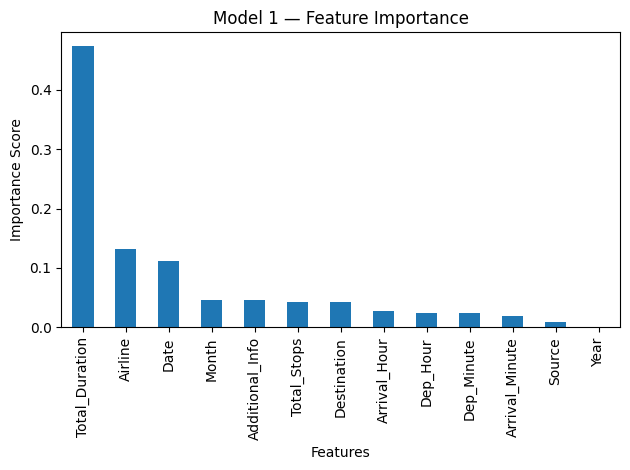

In [46]:
fi_v1.plot(kind='bar')
plt.title('Model 1 — Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

Observation: Model 1 mein Year ka importance 0 nikla. Sochte hain ki Year ko hata dein but jab hataya toh accuracy kam ho gayi - isliye rakha. Total_Duration aur Airline sabse zyada important features hain.

## Model 2 — Extra Features (Duration_Hour, Duration_Min, Dep_Time_Bucket)

**Features used:** Sab Model 1 wale + Duration_Hour, Duration_Min, Dep_Time_Bucket  
**Model:** RandomForestRegressor (n_estimators=200, max_depth=20)  
**Test size:** 0.2

In [47]:
# Naye features banate hain
final_df['Duration_Hour'] = final_df['Total_Duration'] // 60
final_df['Duration_Min']  = final_df['Total_Duration'] % 60

In [48]:
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 0   # Morning
    elif 12 <= hour < 17:
        return 1   # Afternoon
    elif 17 <= hour < 21:
        return 2   # Evening
    else:
        return 3   # Night

final_df['Dep_Time_Bucket'] = final_df['Dep_Hour'].apply(get_time_of_day)

In [49]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_v2 = final_df.drop(['Price', 'Year'], axis=1)
y_v2 = final_df['Price']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42
)

mask_v2 = y_train_v2.notna()
X_train_v2 = X_train_v2.loc[mask_v2]
y_train_v2 = y_train_v2.loc[mask_v2]

rfg_v2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)
rfg_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = rfg_v2.predict(X_test_v2)

eval_mask_v2 = y_test_v2.notna()
y_test_v2    = y_test_v2.loc[eval_mask_v2]
y_pred_v2    = y_pred_v2[eval_mask_v2.values]

mae_v2  = mean_absolute_error(y_test_v2, y_pred_v2)
mse_v2  = mean_squared_error(y_test_v2, y_pred_v2)
rmse_v2 = np.sqrt(mse_v2)
r2_v2   = r2_score(y_test_v2, y_pred_v2)

print("MAE:",      mae_v2)
print("MSE:",      mse_v2)
print("RMSE:",     rmse_v2)
print("R2 Score:", r2_v2)

fi_v2 = pd.Series(
    rfg_v2.feature_importances_,
    index=X_v2.columns
).sort_values(ascending=False)

print("\nFeature Importance:\n")
print(fi_v2)


MAE: 705.7753923046023
MSE: 4382370.968441135
RMSE: 2093.411323281007
R2 Score: 0.8070755481034103

Feature Importance:

Total_Duration     0.431390
Airline            0.131433
Date               0.100413
Additional_Info    0.061811
Month              0.045998
Total_Stops        0.044663
Destination        0.039957
Duration_Hour      0.035992
Arrival_Hour       0.023329
Dep_Hour           0.019854
Dep_Minute         0.019716
Arrival_Minute     0.016165
Duration_Min       0.014266
Source             0.008399
Dep_Time_Bucket    0.006614
dtype: float64


Observation: When we removed the Year with '0' importance, it caused a lot of affect on the model and it's accuracy got reduced..

In [50]:
from xgboost import XGBRegressor

# Use whichever split variables are already available
if 'y_train' in globals() and 'X_train' in globals() and 'X_test' in globals():
	y_train_used = y_train
	X_train_used = X_train
	X_test_used = X_test
else:
	y_train_used = y_train_v2
	X_train_used = X_train_v2
	X_test_used = X_test_v2

mask = y_train_used.notna()

X_train_clean = X_train_used.loc[mask]
y_train_clean = y_train_used.loc[mask]

xgb_v1 = XGBRegressor(random_state=42)
xgb_v1.fit(X_train_clean, y_train_clean)

y_pred = xgb_v1.predict(X_test_used)

In [51]:
# Build y_test safely (if not already present)
if 'y_test' in globals():
	y_test_eval = y_test.copy()
else:
	y_test_eval = final_df.loc[X_test_used.index, 'Price']

# Remove NaN targets
y_test_eval = y_test_eval.dropna()

# Align predictions with y_test indices
if len(y_pred) == len(X_test_used):
	y_pred_eval = pd.Series(y_pred, index=X_test_used.index).loc[y_test_eval.index].values
else:
	y_pred_eval = y_pred[:len(y_test_eval)]

mae = mean_absolute_error(y_test_eval, y_pred_eval)
rmse = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
r2 = r2_score(y_test_eval, y_pred_eval)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 796.7494595655754
RMSE: 1785.200371630555
R2 Score: 0.8597018080091489


In [52]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_clean, y_train_clean)

rf_pred = rf.predict(X_test_used)

if 'y_test_eval' in globals():
	y_test_used = y_test_eval.copy()
else:
	y_test_used = final_df.loc[X_test_used.index, 'Price'].dropna()

rf_pred = pd.Series(rf_pred, index=X_test_used.index).loc[y_test_used.index].values
xgb_pred = pd.Series(y_pred, index=X_test_used.index).loc[y_test_used.index].values

print("RF RMSE:", np.sqrt(mean_squared_error(y_test_used, rf_pred)))
print("XGB RMSE:", np.sqrt(mean_squared_error(y_test_used, xgb_pred)))

RF RMSE: 2097.4543405451313
XGB RMSE: 1785.200371630555


In [53]:
# RF vs XGB metrics comparison

# True values
if 'y_test_used' in globals():
    y_true = y_test_used.copy()
elif 'y_test_eval' in globals():
    y_true = y_test_eval.copy()
else:
    y_true = final_df.loc[X_test_used.index, 'Price'].dropna()

# RF predictions (aligned)
if 'rf_pred' in globals():
    rf_pred_eval = pd.Series(rf_pred, index=y_true.index).values if len(rf_pred) == len(y_true) else rf_pred[:len(y_true)]
else:
    rf_pred_raw = rf.predict(X_test_used)
    rf_pred_eval = pd.Series(rf_pred_raw, index=X_test_used.index).loc[y_true.index].values

# XGB predictions (prefer improved model if available)
if 'y_pred_v2_eval' in globals():
    xgb_pred_eval = y_pred_v2_eval
    xgb_name = "XGB (v2)"
elif 'xgb_pred' in globals():
    xgb_pred_eval = xgb_pred
    xgb_name = "XGB (v1)"
else:
    xgb_pred_raw = xgb_v1.predict(X_test_used)
    xgb_pred_eval = pd.Series(xgb_pred_raw, index=X_test_used.index).loc[y_true.index].values
    xgb_name = "XGB (v1)"

comparison_df = pd.DataFrame({
    "Model": ["RandomForest", xgb_name],
    "MAE": [
        mean_absolute_error(y_true, rf_pred_eval),
        mean_absolute_error(y_true, xgb_pred_eval)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_true, rf_pred_eval)),
        np.sqrt(mean_squared_error(y_true, xgb_pred_eval))
    ],
    "R2": [
        r2_score(y_true, rf_pred_eval),
        r2_score(y_true, xgb_pred_eval)
    ]
}).sort_values("RMSE")

print(comparison_df)

          Model        MAE         RMSE        R2
1      XGB (v1)  796.74946  1785.200372  0.859702
0  RandomForest  706.51516  2097.454341  0.806330


In [62]:
importance = pd.Series(
    xgb_v1.feature_importances_,
    index=X_train_clean.columns
).sort_values(ascending=False)

print(importance)

Total_Duration     0.294883
Total_Stops        0.142447
Airline            0.135734
Destination        0.099749
Additional_Info    0.098707
Month              0.051344
Date               0.042992
Source             0.025935
Arrival_Hour       0.022908
Dep_Time_Bucket    0.020664
Arrival_Minute     0.019887
Dep_Minute         0.016344
Dep_Hour           0.012874
Duration_Min       0.012607
Duration_Hour      0.002926
dtype: float32


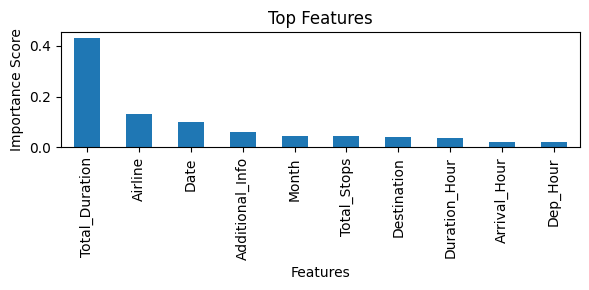

In [58]:
# Ensure importance exists even if the earlier cell was not run
if 'importance' not in globals():
	if 'fi_v2' in globals():
		importance = fi_v2
	elif 'fi_v1' in globals():
		importance = fi_v1
	elif 'xgb_v1' in globals() and 'X_train_clean' in globals():
		importance = pd.Series(
			xgb_v1.feature_importances_,
			index=X_train_clean.columns
		).sort_values(ascending=False)
	else:
		raise NameError("Feature importance is not available. Run the model/importance cell first.")

plt.figure(figsize=(6, 3))
importance.head(10).plot(kind='bar')
plt.title("Top Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [59]:
xgb_v2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_v2.fit(X_train_clean, y_train_clean)

y_pred_v2 = xgb_v2.predict(X_test_used)

# Use available evaluated target if present; otherwise rebuild from final_df
if 'y_test_used' in globals():
    y_true_v2 = y_test_used.copy()
else:
    y_true_v2 = final_df.loc[X_test_used.index, 'Price'].dropna()

# Align predictions with y_true indices
y_pred_v2_eval = pd.Series(y_pred_v2, index=X_test_used.index).loc[y_true_v2.index].values

print("Improved RMSE:", np.sqrt(mean_squared_error(y_true_v2, y_pred_v2_eval)))

Improved RMSE: 1696.4204523642168


In [60]:
import pickle

with open("flight_price_model.pkl", "wb") as f:
    pickle.dump(xgb_v2, f)

In [61]:
sample = X_test_used.iloc[0:1]
print("Predicted Price:", xgb_v2.predict(sample))

Predicted Price: [5042.894]
